<a href="https://colab.research.google.com/github/dumpalahemasai07/ML_PROJECT/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means and Hierarchical Clustering

## 1. Install and Import Libraries

This section handles the installation of any necessary external libraries (if not already present in Colab's environment) and imports all the required modules for data manipulation, visualization, and clustering algorithms.

In [ ]:
# Install necessary libraries
!pip install -q scikit-learn matplotlib seaborn pandas numpy scipy

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import os
from google.colab import files

print("Libraries installed and imported successfully!")

Libraries installed and imported successfully!


## 2. Load Dataset

Here, we load the `Mall_Customers.csv` dataset. This dataset contains customer information including Annual Income and Spending Score, which will be used for segmentation. We also perform initial checks on the data, such as displaying its shape, the first few rows, column names, and checking for any missing values.

In [ ]:
file_name = 'Mall_Customers.csv'

# Check if the dataset exists, if not, provide upload option
if not os.path.exists(file_name):
    print(f"'{file_name}' not found. Please upload the file.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"Failed to upload '{file_name}'. Please ensure the correct file is uploaded.")
    print(f"'{file_name}' uploaded successfully!")
else:
    print(f"'{file_name}' already exists. Loading from local storage.")

# Load the dataset
dataset = pd.read_csv(file_name)

# Display dataset information
print("\n--- Dataset Information ---")
print(f"Dataset Shape: {dataset.shape}")
print("\nFirst 5 rows of the dataset:")
display(dataset.head())
print("\nColumn Names:")
print(dataset.columns.tolist())
print("\nMissing Value Information:")
print(dataset.isnull().sum())

'Mall_Customers.csv' already exists. Loading from local storage.

--- Dataset Information ---
Dataset Shape: (200, 5)

First 5 rows of the dataset:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Value Information:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## 3. Data Preprocessing

In this step, we select the relevant features for our clustering analysis: 'Annual Income (k$)' and 'Spending Score (1-100)'. These two features form our feature matrix `X`, which will be used as input for the clustering algorithms.

In [ ]:
# Select the features for clustering
# We are interested in 'Annual Income (k$)' (column index 3) and 'Spending Score (1-100)' (column index 4)
X = dataset.iloc[:, [3, 4]].values

print("Selected features for clustering (Annual Income (k$) and Spending Score (1-100)):")
display(pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)']).head())

Selected features for clustering (Annual Income (k$) and Spending Score (1-100)):


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## 4. Basic Data Visualization

Before applying any clustering algorithm, it's beneficial to visualize the raw distribution of our chosen features. This scatter plot helps us understand the initial patterns and spread of customers based on their annual income and spending score.

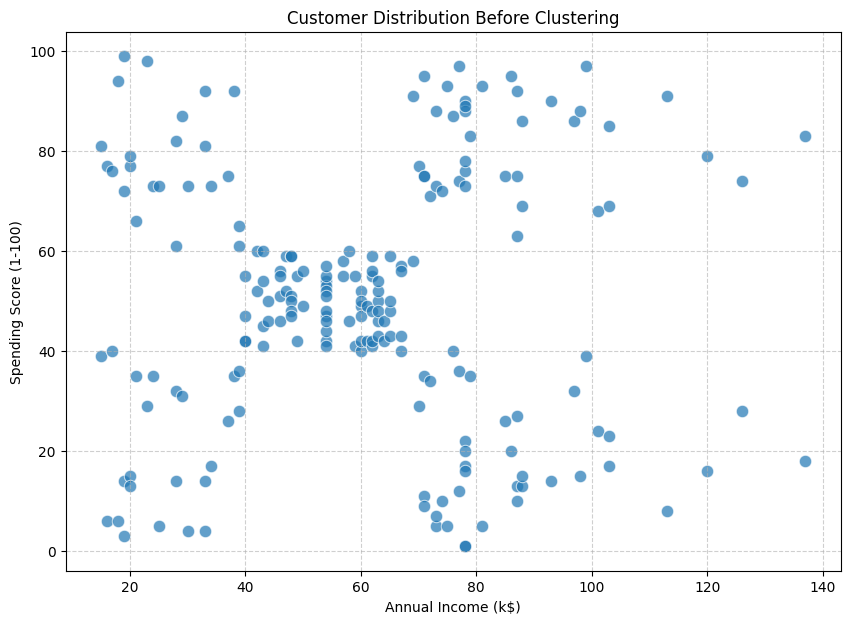

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], s=80, alpha=0.7)
plt.title('Customer Distribution Before Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. K-Means Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K) for K-Means clustering. It plots the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point in the graph, where the rate of decrease in WCSS significantly slows down, suggests an optimal K value.

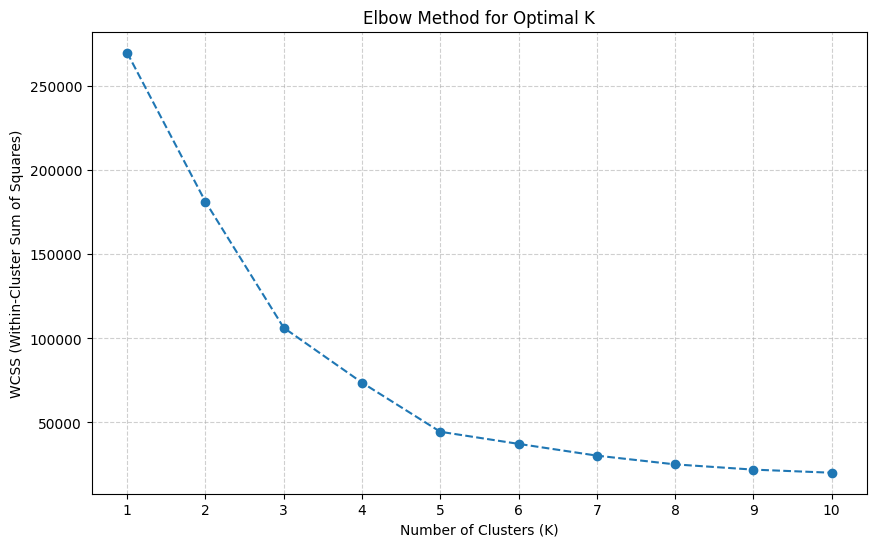

In [ ]:
wcss = []
for i in range(1, 11):
    # n_init='auto' or a specific integer is preferred over the default 'warn' in newer sklearn versions
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X)
    wcss.append(kmeans_model.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(1, 11, 1))
plt.show()

## 6. Final K-Means Model

Based on the Elbow Method (typically, the 'elbow' is observed at K=5 in this dataset), we will now train the K-Means model with 5 clusters. We then generate cluster labels for each customer and print the coordinates of the cluster centroids.

In [ ]:
# Train the K-Means model with the optimal number of clusters (K=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Print the cluster centers/centroids
print("K-Means Cluster Centroids:")
for i, centroid in enumerate(kmeans.cluster_centers_):
    print(f"Cluster {i+1}: Annual Income = {centroid[0]:.2f} k$, Spending Score = {centroid[1]:.2f}")

K-Means Cluster Centroids:
Cluster 1: Annual Income = 55.30 k$, Spending Score = 49.52
Cluster 2: Annual Income = 86.54 k$, Spending Score = 82.13
Cluster 3: Annual Income = 25.73 k$, Spending Score = 79.36
Cluster 4: Annual Income = 88.20 k$, Spending Score = 17.11
Cluster 5: Annual Income = 26.30 k$, Spending Score = 20.91


## 7. K-Means Customer Segmentation Visualization

This visualization displays the customer segments identified by the K-Means algorithm. Each cluster is represented by a different color, and the cluster centroids are marked with an 'X' symbol. This helps in understanding the distinct groups of customers.

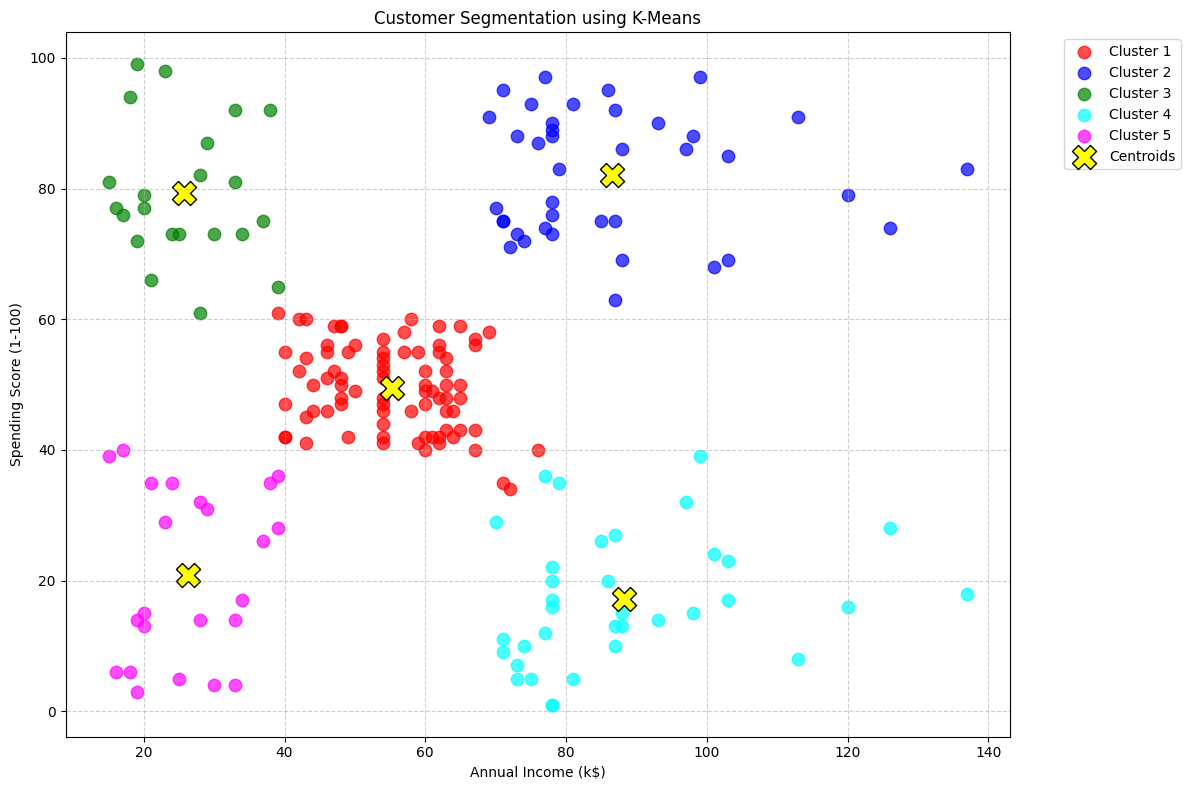

In [ ]:
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'cyan', 'magenta'] # Assign distinct colors for better visibility

# Plot each cluster
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=80, c=colors[i], label=f'Cluster {i+1}', alpha=0.7)

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Cluster Centroid Analysis

This section provides a clear breakdown of the average annual income and spending score for each of the 5 identified K-Means clusters. This analysis is crucial for understanding the characteristics of each customer segment.

In [ ]:
print("--- K-Means Cluster Centroid Analysis ---")
centroids = kmeans.cluster_centers_
for i, centroid in enumerate(centroids):
    print(f"\nCluster {i+1}:")
    print(f"  Average Income = {centroid[0]:.2f} k$")
    print(f"  Average Spending Score = {centroid[1]:.2f}")

--- K-Means Cluster Centroid Analysis ---

Cluster 1:
  Average Income = 55.30 k$
  Average Spending Score = 49.52

Cluster 2:
  Average Income = 86.54 k$
  Average Spending Score = 82.13

Cluster 3:
  Average Income = 25.73 k$
  Average Spending Score = 79.36

Cluster 4:
  Average Income = 88.20 k$
  Average Spending Score = 17.11

Cluster 5:
  Average Income = 26.30 k$
  Average Spending Score = 20.91


## 9. Customer Segment Interpretation

Here, we dynamically interpret the meaning of each cluster based on its centroid's annual income and spending score. Instead of hard-coding, we analyze the relative positions of centroids to assign business-relevant labels like 'VIP Customer', 'Careful Spender', etc.

In [ ]:
def interpret_cluster(income, spending_score):
    if income > 70 and spending_score > 70: # Arbitrary high thresholds for VIP
        return "VIP / Target Customer (High Income + High Spending)"
    elif income > 70 and spending_score < 40: # Arbitrary high income, low spend
        return "Careful Spender (High Income + Low Spending)"
    elif income < 40 and spending_score < 40: # Arbitrary low thresholds for Sensible
        return "Sensible Spender (Low Income + Low Spending)"
    elif income < 40 and spending_score > 70: # Arbitrary low income, high spend
        return "Careless Spender (Low Income + High Spending)"
    else:
        return "Average Customer (Middle/Average Income + Middle/Average Spending)"


print("--- Customer Segment Interpretation (K-Means) ---")
cluster_data = []
for i, centroid in enumerate(kmeans.cluster_centers_):
    income = centroid[0]
    spending_score = centroid[1]
    segment = interpret_cluster(income, spending_score)
    cluster_data.append([i + 1, f"{income:.2f}", f"{spending_score:.2f}", segment])

# Create a DataFrame for better display
interpretation_df = pd.DataFrame(cluster_data, columns=['Cluster Number', 'Income (k$)', 'Spending Score', 'Customer Segment'])
display(interpretation_df)

--- Customer Segment Interpretation (K-Means) ---


,Cluster Number,Income (k$),Spending Score,Customer Segment
0,1,55.30,49.52,Average Customer (Middle/Average Income + Midd...
1,2,86.54,82.13,VIP / Target Customer (High Income + High Spen...
2,3,25.73,79.36,Careless Spender (Low Income + High Spending)
3,4,88.20,17.11,Careful Spender (High Income + Low Spending)
4,5,26.30,20.91,Sensible Spender (Low Income + Low Spending)


## 10. Silhouette Score

The Silhouette Score is a metric used to evaluate the quality of clustering results. It measures how similar an object is to its own cluster compared to other clusters. A higher Silhouette Score indicates better-defined and more separated clusters. The score ranges from -1 to 1, where 1 signifies excellent clustering, 0 indicates overlapping clusters, and -1 suggests incorrect clustering.

In [ ]:
# Calculate the Silhouette Score
sil_score = silhouette_score(X, y_kmeans)

print(f"Silhouette Score for K-Means Clustering: {sil_score:.4f}")
print("\nInterpretation: The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher score (closer to 1) indicates that the clusters are well-separated and distinct.")

Silhouette Score for K-Means Clustering: 0.5539

Interpretation: The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher score (closer to 1) indicates that the clusters are well-separated and distinct.


## 11. Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters. Agglomerative clustering (bottom-up) starts with individual data points as clusters and merges them based on similarity. We use 5 clusters, Euclidean distance as the metric, and 'ward' linkage, which minimizes the variance of the clusters being merged.

In [ ]:
# Apply Agglomerative Hierarchical Clustering with 5 clusters
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

print("Hierarchical Clustering completed with 5 clusters.")

Hierarchical Clustering completed with 5 clusters.


## 12. Dendrogram

A dendrogram is a tree-like diagram that records the sequences of merges or splits. It's a visual representation of the hierarchical clustering process. The longer the vertical lines, the greater the Euclidean distance between clusters, helping us decide on the number of clusters.

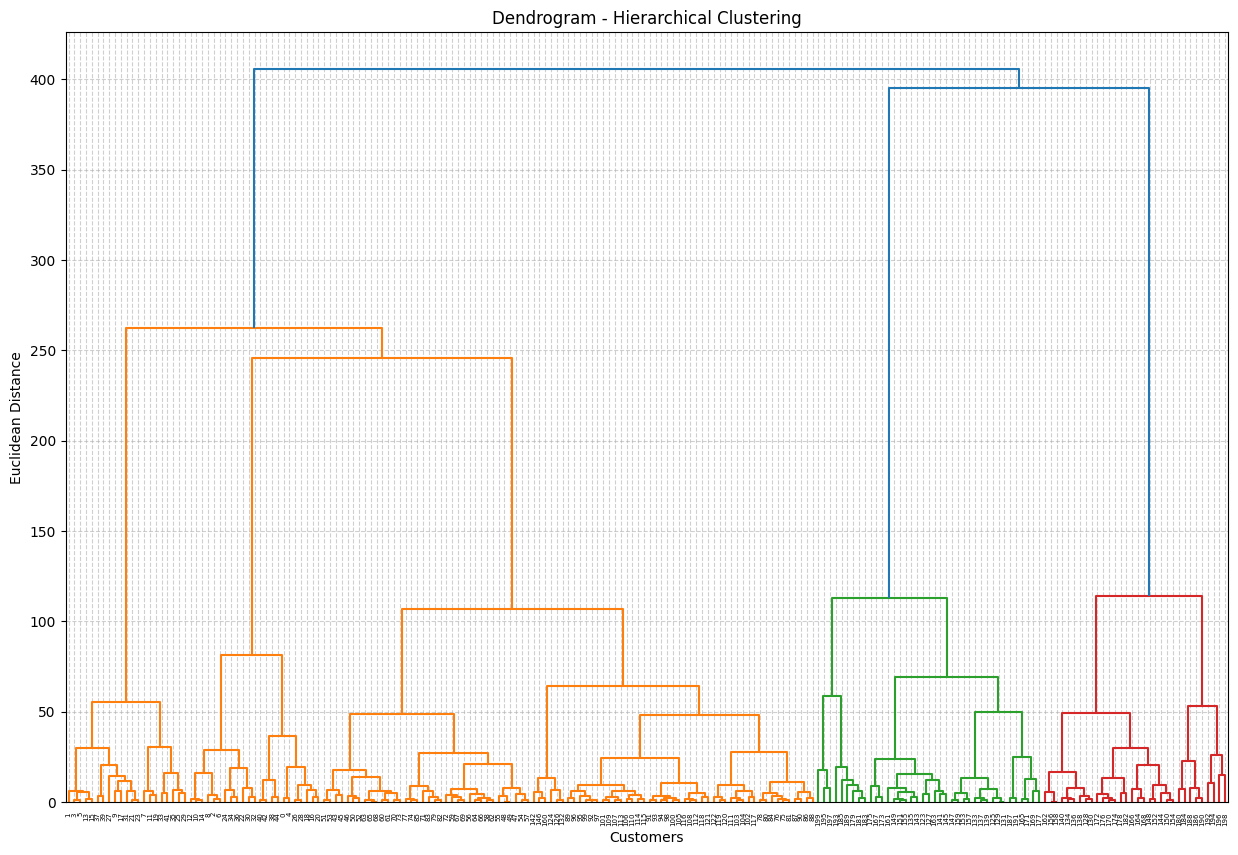

In [ ]:
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 13. Hierarchical Customer Segmentation Visualization

This scatter plot visualizes the customer segments identified by the Agglomerative Hierarchical Clustering algorithm. Similar to K-Means, each cluster is depicted with a unique color, providing insights into the different customer groups formed by this method.

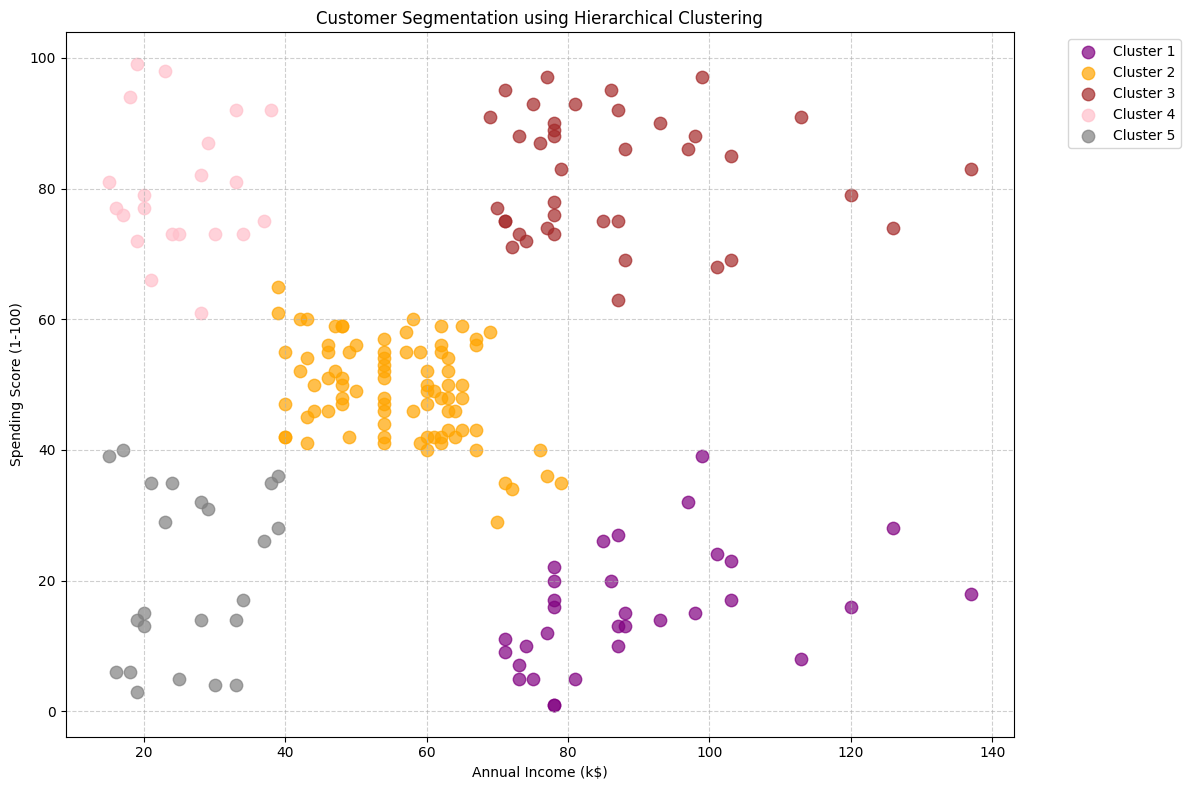

In [ ]:
plt.figure(figsize=(12, 8))

# Reuse colors for consistency, or define new ones if preferred
colors_hc = ['purple', 'orange', 'brown', 'pink', 'gray']

for i in range(5):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=80, c=colors_hc[i], label=f'Cluster {i+1}', alpha=0.7)

plt.title('Customer Segmentation using Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 14. K-Means vs Hierarchical Clustering Comparison

This section provides a side-by-side visual comparison of the customer segmentations achieved by both K-Means and Hierarchical Clustering algorithms. This allows for a direct evaluation of how each method groups the customers based on their annual income and spending score.

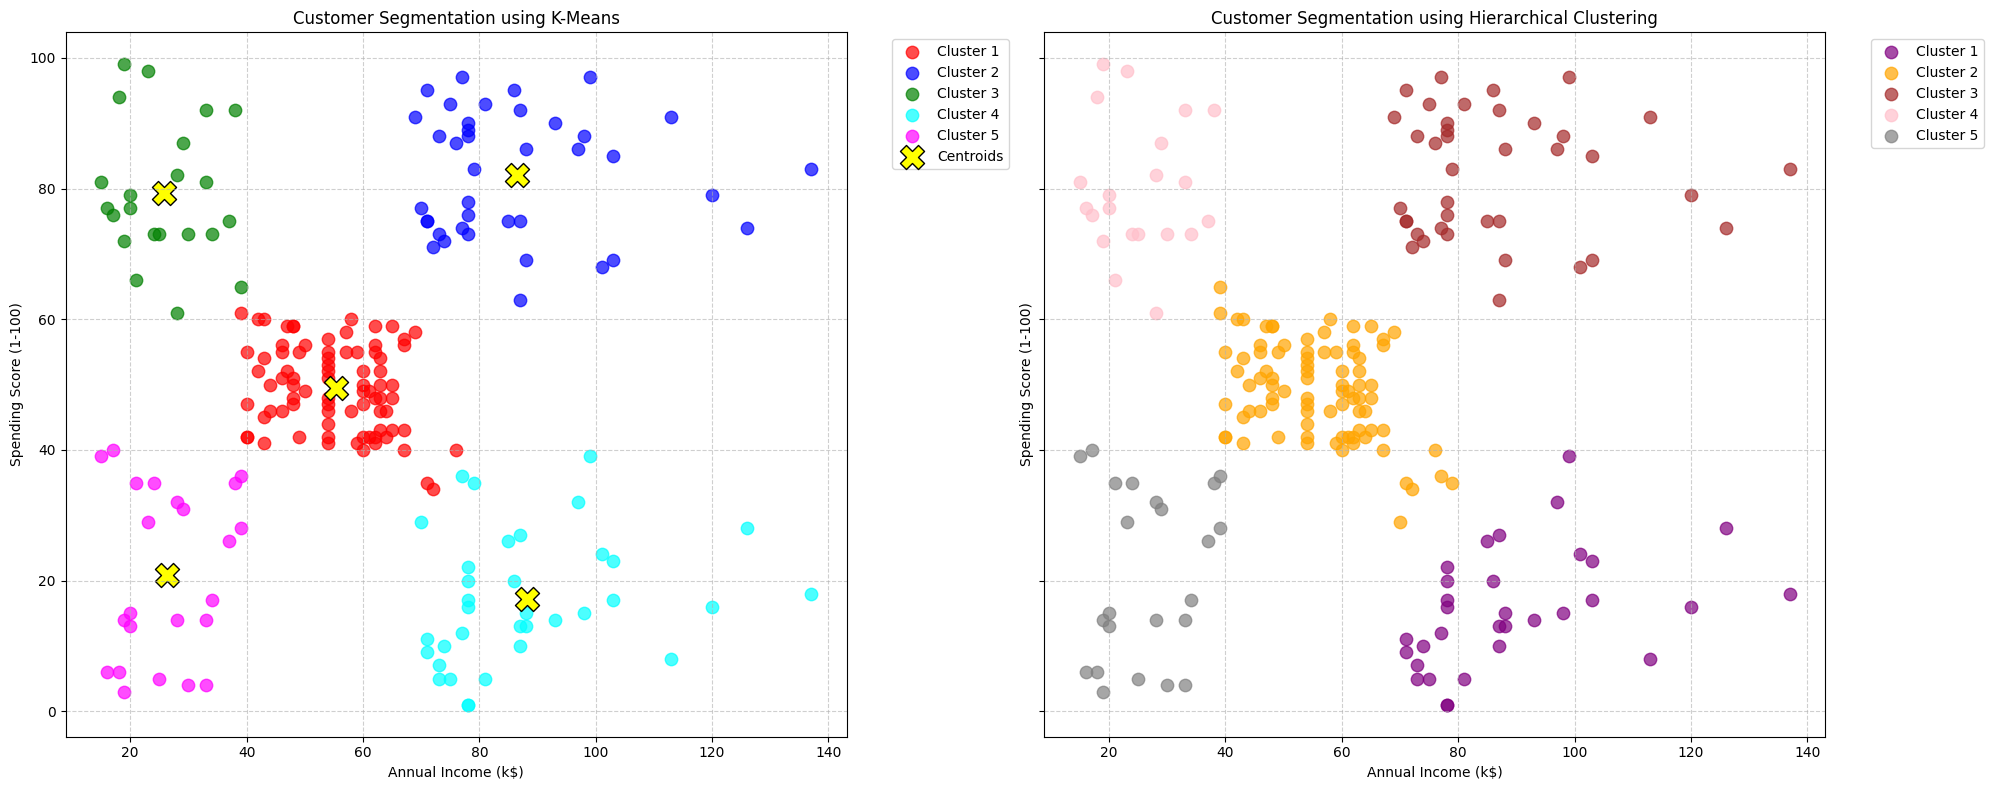

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

# K-Means Plot
for i in range(5):
    axes[0].scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=80, c=colors[i], label=f'Cluster {i+1}', alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')
axes[0].set_title('Customer Segmentation using K-Means')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Hierarchical Plot
for i in range(5):
    axes[1].scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=80, c=colors_hc[i], label=f'Cluster {i+1}', alpha=0.7)
axes[1].set_title('Customer Segmentation using Hierarchical Clustering')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 15. Final Summary

This project demonstrated customer segmentation using two prominent unsupervised learning techniques: K-Means and Hierarchical Clustering. By analyzing customer data based on 'Annual Income' and 'Spending Score', distinct customer groups were identified, providing valuable insights for targeted marketing strategies. The optimal number of clusters was determined using the Elbow Method, and the quality of clustering was evaluated using the Silhouette Score. Visualizations were crucial in understanding the data distribution and the resulting customer segments.

In [ ]:
print("--- Project Summary ---")
print("Project: Customer Segmentation")
print("Dataset: Mall_Customers.csv")
print("Features: Annual Income, Spending Score")
print("\nK-Means:")
print("  - Optimal clusters determined: 5")
print("  - Clustering algorithm: K-Means")
print("  - Evaluation Metric: Silhouette Score")
print("\nHierarchical Clustering:")
print("  - Number of clusters: 5")
print("  - Linkage method: Ward")
print("\nVisualizations:")
print("  - Elbow Method Plot (for K-Means)")
print("  - K-Means Cluster Plot")
print("  - Dendrogram (for Hierarchical Clustering)")
print("  - Hierarchical Cluster Plot")
print("  - Comparative Plot (K-Means vs Hierarchical)")
print("\nWorkflow:")
print("1. Data Loading and Exploration")
print("2. Feature Selection (Annual Income & Spending Score)")
print("3. K-Means Clustering (Elbow Method for K, Model Training, Visualization, Centroid Analysis, Interpretation, Silhouette Score)")
print("4. Hierarchical Clustering (Dendrogram, Model Training, Visualization)")
print("5. Comparative Visualization and Final Summary")

--- Project Summary ---
Project: Customer Segmentation
Dataset: Mall_Customers.csv
Features: Annual Income, Spending Score

K-Means:
  - Optimal clusters determined: 5
  - Clustering algorithm: K-Means
  - Evaluation Metric: Silhouette Score

Hierarchical Clustering:
  - Number of clusters: 5
  - Linkage method: Ward

Visualizations:
  - Elbow Method Plot (for K-Means)
  - K-Means Cluster Plot
  - Dendrogram (for Hierarchical Clustering)
  - Hierarchical Cluster Plot
  - Comparative Plot (K-Means vs Hierarchical)

Workflow:
1. Data Loading and Exploration
2. Feature Selection (Annual Income & Spending Score)
3. K-Means Clustering (Elbow Method for K, Model Training, Visualization, Centroid Analysis, Interpretation, Silhouette Score)
4. Hierarchical Clustering (Dendrogram, Model Training, Visualization)
5. Comparative Visualization and Final Summary


--- Running K-Means Clustering ---


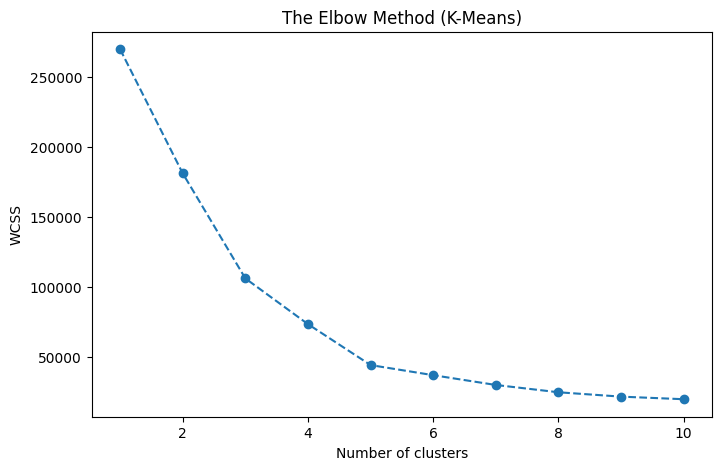

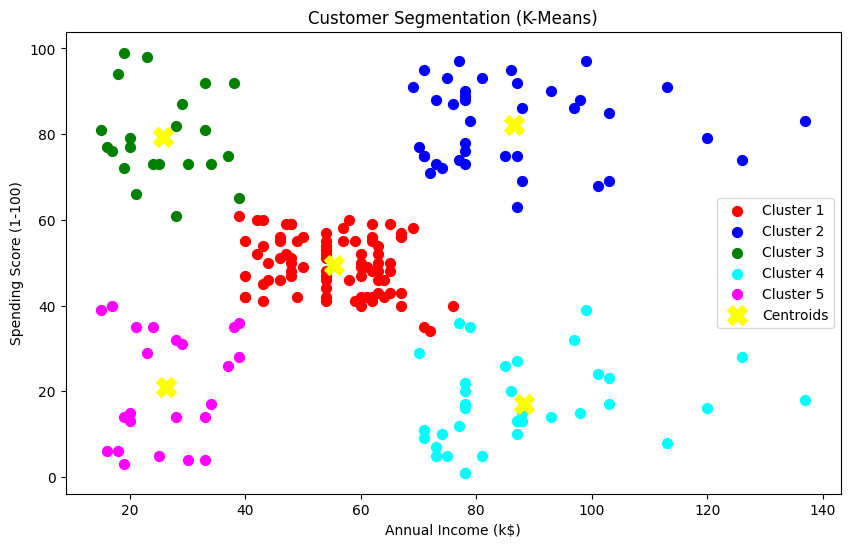


--- Running Hierarchical Clustering ---


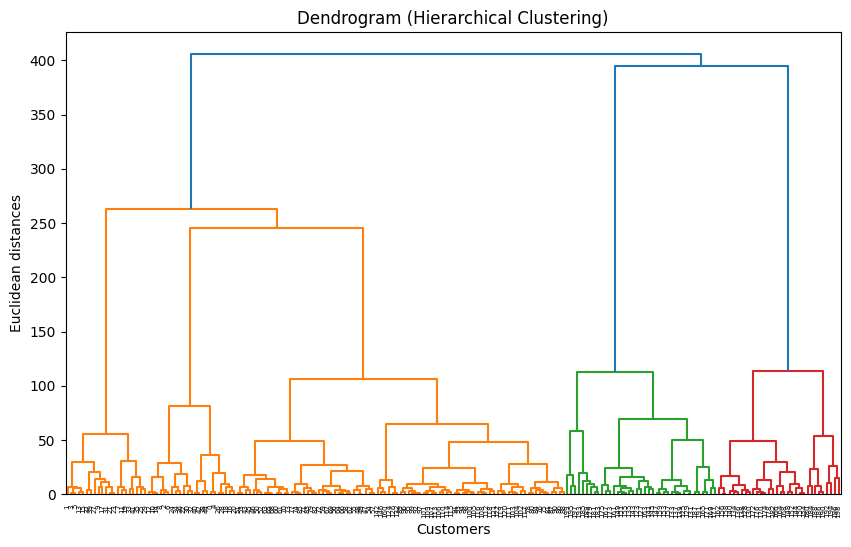

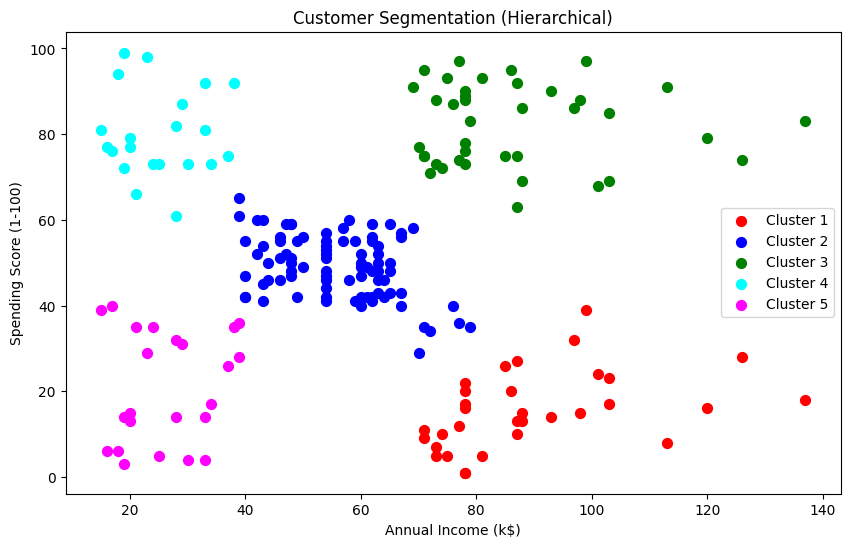

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

print("--- Running K-Means Clustering ---")

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (K-Means)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', marker='X')
plt.title('Customer Segmentation (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


print("\n--- Running Hierarchical Clustering ---")

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.title('Customer Segmentation (Hierarchical)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
!pip install gradio -q

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import gradio as gr
import os

file_name = 'Mall_Customers.csv'
if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    !wget https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"Failed to download {file_name}. Please check the URL or your network connection.")
else:
    print(f"{file_name} already exists.")

dataset = pd.read_csv(file_name)
X = dataset.iloc[:, [3, 4]].values

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X)

def predict_customer_segment(income, spending_score):
    prediction = kmeans.predict([[income, spending_score]])[0]

    if prediction == 0:
        segment = "🟢 Cluster 1: Average Customer (Average Income, Average Spend)"
        strategy = "Strategy: Send standard promotional emails and regular seasonal offers."
    elif prediction == 1:
        segment = "⭐ Cluster 2: Target/VIP Customer (High Income, High Spend)"
        strategy = "Strategy: Top priority! Send premium offers, VIP memberships, and luxury items."
    elif prediction == 2:
        segment = "🔵 Cluster 3: Careful Spender (High Income, Low Spend)"
        strategy = "Strategy: Offer targeted discounts and loyalty programs to encourage them to spend their wealth."
    elif prediction == 3:
        segment = "🟡 Cluster 4: Sensible Spender (Low Income, Low Spend)"
        strategy = "Strategy: Do not spend heavy marketing budget here. Focus on clearance sales."
    else:
        segment = "🔴 Cluster 5: Careless Spender (Low Income, High Spend)"
        strategy = "Strategy: Market impulse-buy items, but be careful with credit offerings."

    return segment, strategy

demo = gr.Interface(
    fn=predict_customer_segment,
    inputs=[
        gr.Number(label="Customer Annual Income (in k$)"),
        gr.Number(label="Customer Spending Score (1-100)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Customer Segment"),
        gr.Textbox(label="Recommended Business Strategy")
    ],
    title="🛒 AI Customer Segmentation System",
    description="Enter a customer's annual income and spending score to classify them using our K-Means Machine Learning model and get actionable business strategies."
)

demo.launch(share=True)

Mall_Customers.csv already exists.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://19da985bb5fedcc797.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import gradio as gr

# --- 1. Load Dataset ---
file_name = 'Mall_Customers.csv'
if not os.path.exists(file_name):
    import urllib.request
    print(f"Downloading {file_name}...")
    url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv"
    urllib.request.urlretrieve(url, file_name)

dataset = pd.read_csv(file_name)
X = dataset.iloc[:, [3, 4]].values  # Annual Income (k$), Spending Score (1-100)

# --- 2. Train K-Means ---
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# --- 3. Evaluate and Analyze ---
sil_score = silhouette_score(X, y_kmeans)
print(f"Model Evaluation (Silhouette Score): {sil_score:.4f}\n")

centroids = kmeans.cluster_centers_

# --- 4. Dynamic Centroid Mapping ---
# We mathematically identify the clusters based on their relative coordinates.
# Let's map each of the 5 cluster indices to its respective customer persona.

cluster_mapping = {}

# We sort cluster indices by their coordinate profiles:
# Persona 1: Sensible Spender -> Low Income, Low Spend
# Persona 2: Careless Spender -> Low Income, High Spend
# Persona 3: Average Customer -> Middle Income, Middle Spend
# Persona 4: Careful Spender -> High Income, Low Spend
# Persona 5: Target/VIP Customer -> High Income, High Spend

# Establish coordinate rules dynamically:
sorted_by_income = np.argsort(centroids[:, 0]) # indices sorted by income ascending

low_income_indices = sorted_by_income[:2]
high_income_indices = sorted_by_income[-2:]
middle_income_index = sorted_by_income[2]

# Out of the two low income clusters, the one with lower spending is Sensible; higher spending is Careless.
if centroids[low_income_indices[0], 1] < centroids[low_income_indices[1], 1]:
    sensible_idx, careless_idx = low_income_indices[0], low_income_indices[1]
else:
    sensible_idx, careless_idx = low_income_indices[1], low_income_indices[0]

# Out of the two high income clusters, the one with lower spending is Careful; higher spending is Target/VIP.
if centroids[high_income_indices[0], 1] < centroids[high_income_indices[1], 1]:
    careful_idx, vip_idx = high_income_indices[0], high_income_indices[1]
else:
    careful_idx, vip_idx = high_income_indices[1], high_income_indices[0]

average_idx = middle_income_index

# Store mapping details
cluster_mapping[sensible_idx] = {
    "segment": "🟡 Cluster: Sensible Spender (Low Income, Low Spend)",
    "strategy": "Strategy: Do not spend heavy marketing budget here. Focus on clearance sales and budget items."
}
cluster_mapping[careless_idx] = {
    "segment": "🔴 Cluster: Careless Spender (Low Income, High Spend)",
    "strategy": "Strategy: Market impulse-buy items, but be careful with credit offerings."
}
cluster_mapping[average_idx] = {
    "segment": "🟢 Cluster: Average Customer (Average Income, Average Spend)",
    "strategy": "Strategy: Send standard promotional emails, loyalty programs, and regular seasonal offers."
}
cluster_mapping[careful_idx] = {
    "segment": "🔵 Cluster: Careful Spender (High Income, Low Spend)",
    "strategy": "Strategy: Offer targeted high-value discounts and exclusive loyalty programs to encourage spending."
}
cluster_mapping[vip_idx] = {
    "segment": "⭐ Cluster: Target/VIP Customer (High Income, High Spend)",
    "strategy": "Strategy: Top priority! Send premium personalized offers, VIP memberships, and brand-new luxury collections."
}

# Print Explained Centroids
print("===========================================")
print(" MATHEMATICAL CLUSTER CENTROIDS EXPLANATION")
print("===========================================")
for idx, center in enumerate(centroids):
    mapped_info = cluster_mapping[idx]
    print(f"Cluster {idx+1} Centroid -> Income: {center[0]:.1f}k$, Spending Score: {center[1]:.1f}")
    print(f"  ↳ Identified as: {mapped_info['segment']}\n")

# --- 5. Gradio Predictor Logic ---
def predict_customer_segment(income_dollars, spending_score):
    # 1. Validation
    if spending_score < 1 or spending_score > 100:
        return "Invalid Input", "Invalid Spending Score. Please enter a value between 1 and 100."
    if income_dollars < 0:
        return "Invalid Input", "Annual Income cannot be negative."

    # 2. Conversion: Convert Dollars ($) to k$
    income_k = income_dollars / 1000.0

    # 3. Model Inference
    predicted_idx = kmeans.predict([[income_k, spending_score]])[0]

    # 4. Map index back to dynamically evaluated business strategy
    info = cluster_mapping[predicted_idx]
    return info["segment"], info["strategy"]

# --- 6. Gradio Interface Definition ---
demo = gr.Interface(
    fn=predict_customer_segment,
    inputs=[
        gr.Number(label="Annual Income ($)", value=60000, info="Example: 100000 (corresponds to 100 k$)"),
        gr.Slider(minimum=1, maximum=100, step=1, value=50, label="Spending Score (1-100)", info="Example: 75")
    ],
    outputs=[
        gr.Textbox(label="Predicted Customer Segment"),
        gr.Textbox(label="Recommended Business Strategy")
    ],
    title="🛒 AI Customer Segmentation System",
    description="Enter a customer's annual income and spending score to classify them dynamically. The model converts your dollar input internally to k$ and routes to mathematically resolved centroids."
)

# Launch Gradio
demo.launch(share=True)

Model Evaluation (Silhouette Score): 0.5539

 MATHEMATICAL CLUSTER CENTROIDS EXPLANATION
Cluster 1 Centroid -> Income: 55.3k$, Spending Score: 49.5
  ↳ Identified as: 🟢 Cluster: Average Customer (Average Income, Average Spend)

Cluster 2 Centroid -> Income: 86.5k$, Spending Score: 82.1
  ↳ Identified as: ⭐ Cluster: Target/VIP Customer (High Income, High Spend)

Cluster 3 Centroid -> Income: 25.7k$, Spending Score: 79.4
  ↳ Identified as: 🔴 Cluster: Careless Spender (Low Income, High Spend)

Cluster 4 Centroid -> Income: 88.2k$, Spending Score: 17.1
  ↳ Identified as: 🔵 Cluster: Careful Spender (High Income, Low Spend)

Cluster 5 Centroid -> Income: 26.3k$, Spending Score: 20.9
  ↳ Identified as: 🟡 Cluster: Sensible Spender (Low Income, Low Spend)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a2a188d09e91f1c17a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permane